In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [7]:
fashion_mnist = keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


In [8]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [9]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

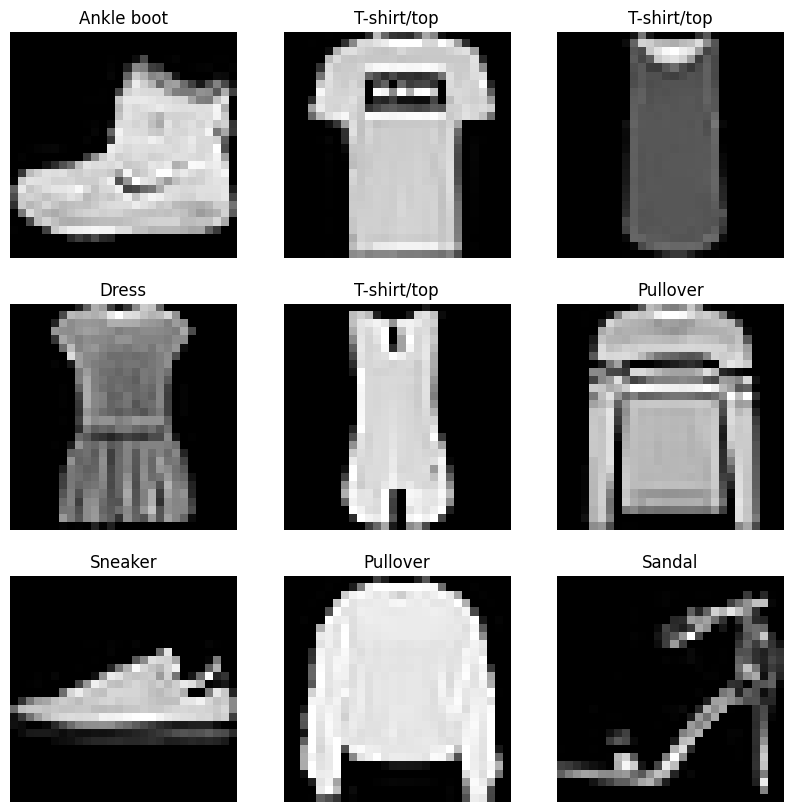

In [10]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [11]:
model = keras.Sequential([

    # Flatten 28x28 image into 1D vector
    layers.Flatten(input_shape=(28,28)),

    # Hidden layer 1
    layers.Dense(128, activation='relu'),

    # Hidden layer 2
    layers.Dense(64, activation='relu'),

    # Output layer
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8175 - loss: 0.5075 - val_accuracy: 0.8533 - val_loss: 0.4059
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8648 - loss: 0.3743 - val_accuracy: 0.8654 - val_loss: 0.3653
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8738 - loss: 0.3414 - val_accuracy: 0.8738 - val_loss: 0.3590
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8835 - loss: 0.3147 - val_accuracy: 0.8748 - val_loss: 0.3447
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8906 - loss: 0.2963 - val_accuracy: 0.8808 - val_loss: 0.3394
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8934 - loss: 0.2838 - val_accuracy: 0.8755 - val_loss: 0.3412
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8994 - loss: 0.2701 - val_accuracy: 0.8852 - val_loss: 0.3243
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9024 - loss: 0.2589 -

In [14]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8807 - loss: 0.3558
Test Accuracy: 0.8806999921798706


In [15]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)

print("Predicted Class:", class_names[predicted_classes[0]])
print("Actual Class:", class_names[y_test[0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Class: Ankle boot
Actual Class: Ankle boot


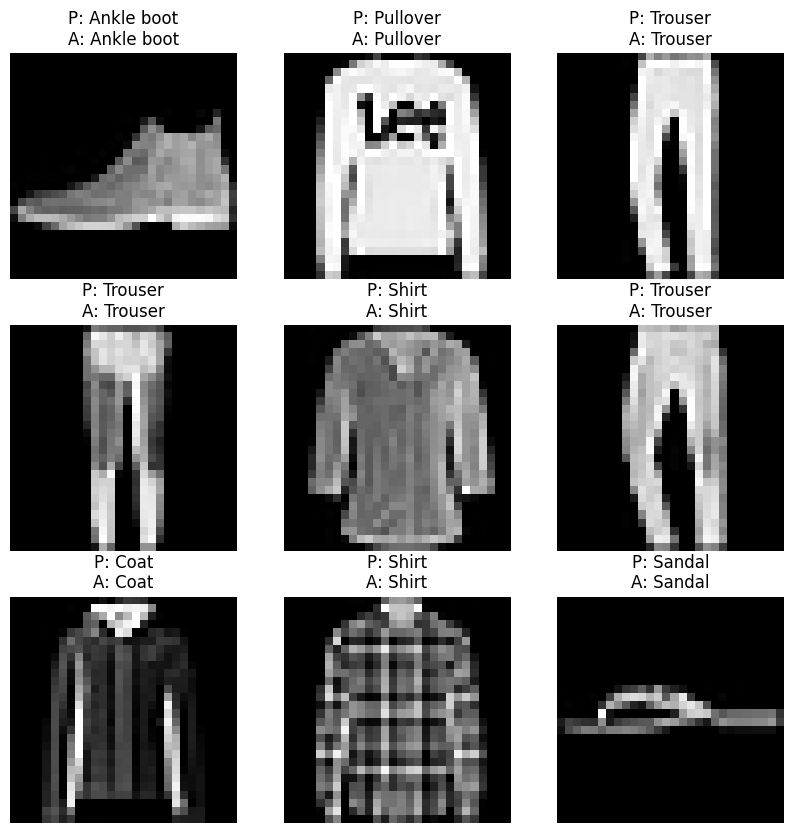

In [16]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(x_test[i], cmap='gray')

    predicted_label = class_names[predicted_classes[i]]
    actual_label = class_names[y_test[i]]

    plt.title(f"P: {predicted_label}\nA: {actual_label}")

    plt.axis('off')

plt.show()

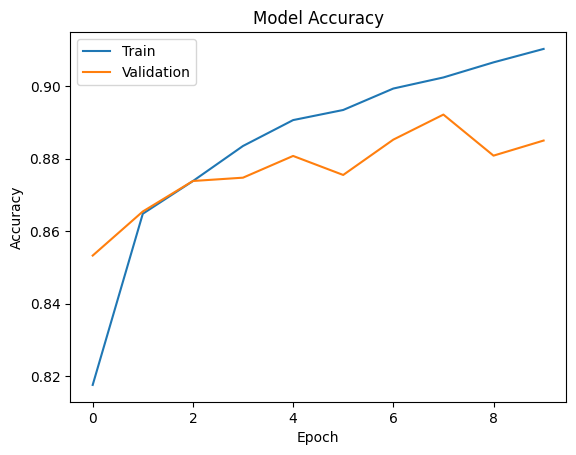

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

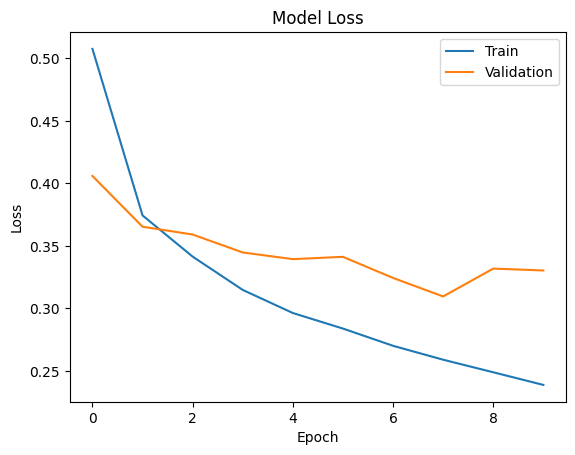

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

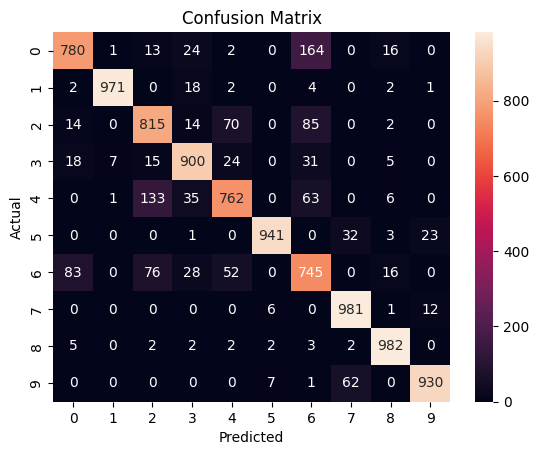

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_classes)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()